# Trabajo Práctico 1 - Ciencia de Datos (FIUBA)

## Análisis Exploratorio y Modelado de Degradación Turbofán (NASA C-MAPSS - FD001)

In [1]:
# Instalación y descarga del conjunto de datos desde KaggleHub
!pip install -q kagglehub

import os
import kagglehub
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Descarga del dataset
path = kagglehub.dataset_download(
    "bishals098/nasa-turbofan-engine-degradation-simulation"
)
print("Ruta de los archivos descargados:", path)
print("Archivos disponibles:", os.listdir(path))

100%|██████████| 12.3M/12.3M [00:00<00:00, 67.6MB/s]

Extracting files...


Ruta de los archivos descargados: /root/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1
Archivos disponibles: ['RUL_FD001.txt', 'RUL_FD003.txt', 'Damage Propagation Modeling.pdf', 'readme.txt', 'train_FD003.txt', 'test_FD003.txt', 'RUL_FD002.txt', 'test_FD002.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD004.txt', 'test_FD001.txt', 'test_FD004.txt', 'RUL_FD004.txt']


## 1. Datos y estructura de dataset

Cada registro del subconjunto `train_FD001.txt` contiene un vector de telemetría por cada ciclo de vuelo.
* **Columna 1:** Identificador único de unidad motriz (`engine_id`).
* **Columna 2:** Ciclo operacional de vuelo (`cycle`).
* **Columnas 3 a 5:** Ajustes operacionales (`setting1`, `setting2`, `setting3`).
* **Columnas 6 a 26:** 21 mediciones de sensores termodinámicos y mecánicos. A continuación, el detalle de las variables monitorizadas:

| Símbolo | Descripción Física del Sensor | Unidad |
| :--- | :--- | :--- |
| **T2 / T24 / T30 / T50** | *Total temperature* - Temperatura total en: entrada del ventilador (*Fan inlet*), salida del compresor de baja presión (*LPC outlet*), salida del compresor de alta presión (*HPC outlet*) y salida de la turbina de baja presión (*LPT outlet*). | °R (Rankine) |
| **P2 / P15 / P30** | *Pressure* - Presión total en: entrada del ventilador (*Fan inlet*), conducto de derivación (*Bypass-duct*) y salida del compresor de alta presión (*HPC outlet*). | psia |
| **Nf / Nc** | *Fan speed* - Velocidad del ventilador / *Core speed* - Velocidad del núcleo. | rpm |
| **epr** | *Engine Pressure Ratio* - Relación de presión del motor (P50/P2). | - |
| **Ps30** | *Static pressure* - Presión estática en la salida del compresor de alta presión (*HPC outlet*). | psia |
| **phi** | *Fuel flow ratio to Ps30* - Relación de flujo de combustible respecto a Ps30. | pps/psi |
| **NRf / NRc** | *Corrected fan speed* - Velocidad corregida del ventilador / *Corrected core speed* - Velocidad corregida del núcleo. | rpm |
| **BPR** | *Bypass Ratio* - Relación de derivación: flujo secundario vs. primario. | - |
| **farB** | *Burner fuel-air ratio* - Relación combustible-aire en la cámara de combustión (*Burner*). | - |
| **htBleed** | *Bleed Enthalpy* - Entalpía de purga (*Bleed* = purga de aire). | BTU/lbm |
| **Nf_dmd / PCNfR_dmd** | *Demanded fan speed* - Velocidad del ventilador demandada (física) / *Demanded corrected fan speed* - Velocidad demandada corregida. | rpm |
| **W31 / W32** | *HPT coolant bleed* - Purga de refrigerante en la turbina de alta presión (*HPT*) / *LPT coolant bleed* - Purga de refrigerante en la turbina de baja presión (*LPT*). | lbm/s |

# PANDAS
## 1. Estructuración y Limpieza Inicial de Datos

In [2]:
train001_file_path = os.path.join(path, "train_FD001.txt")

# Lectura del archivo delimitado por espacios en blanco
train_df = pd.read_csv(train001_file_path, sep=r"\s+", header=None)
train_df = train_df.dropna(axis=1, how="all")

# Definición de nombres de columnas según documentación técnica (Tablas 1 y 2)
column_names = ["engine_id", "cycle"]
operational_settings = ["setting1", "setting2", "setting3"]
sensor_names = [
    "T2",
    "T24",
    "T30",
    "T50",
    "P2",
    "P15",
    "P30",
    "Nf",
    "Nc",
    "epr",
    "Ps30",
    "phi",
    "NRf",
    "NRc",
    "BPR",
    "farB",
    "htBleed",
    "Nf_dmd",
    "PCNfR_dmd",
    "W31",
    "W32",
]

train_df.columns = column_names + operational_settings + sensor_names

print(f"Dimensiones iniciales del dataset: {train_df.shape}")
print(f"Valores nulos en el dataset: {train_df.isnull().sum().sum()}")

Dimensiones iniciales del dataset: (20631, 26)
Valores nulos en el dataset: 0


### Filtrado de Atributos con Varianza Nula
Se buscan columnas con desviación estándar prácticamente nula ($\sigma < 10^{-6}$), las cuales no aportan variabilidad y generan redundancia numérica en los algoritmos.

In [3]:
columnas_constantes = train_df.columns[train_df.std(numeric_only=True) < 1e-6]
print("Columnas sin varianza en FD001:", list(columnas_constantes))

train_df_filtro = train_df.drop(columns=columnas_constantes)

print("Dimensiones tras el filtrado:", train_df_filtro.shape)

Columnas sin varianza en FD001: ['setting3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Dimensiones tras el filtrado: (20631, 19)


### Cálculo del Target: Vida Útil Remanente ($RUL$)
Definimos el $Remaining Useful Life$ - Vida Util Remanente ($RUL$) de cada fila como la diferencia entre el ciclo máximo que alcanzó ese motor antes de romperse y el ciclo actual:
$$RUL = \max(\text{cycle}_{\text{motor}}) - \text{cycle}$$

In [4]:
train_df_filtro["RUL"] = (
    train_df_filtro.groupby("engine_id")["cycle"].transform("max")
    - train_df_filtro["cycle"]
)

# Sensores activos tras eliminar columnas constantes
sensores_activos = [
    "T24",
    "T30",
    "T50",
    "P15",
    "P30",
    "Nf",
    "Nc",
    "Ps30",
    "phi",
    "NRf",
    "NRc",
    "BPR",
    "htBleed",
    "W31",
    "W32",
]

---
## 2. Consultas y Análisis Exploratorio de Datos (EDA)

### Consulta 1: Distribución de la Vida Útil Total de los Motores
**Pregunta:** ¿Todos los motores fallan tras la misma cantidad de ciclos operativos o existe una dispersión significativa en su durabilidad?

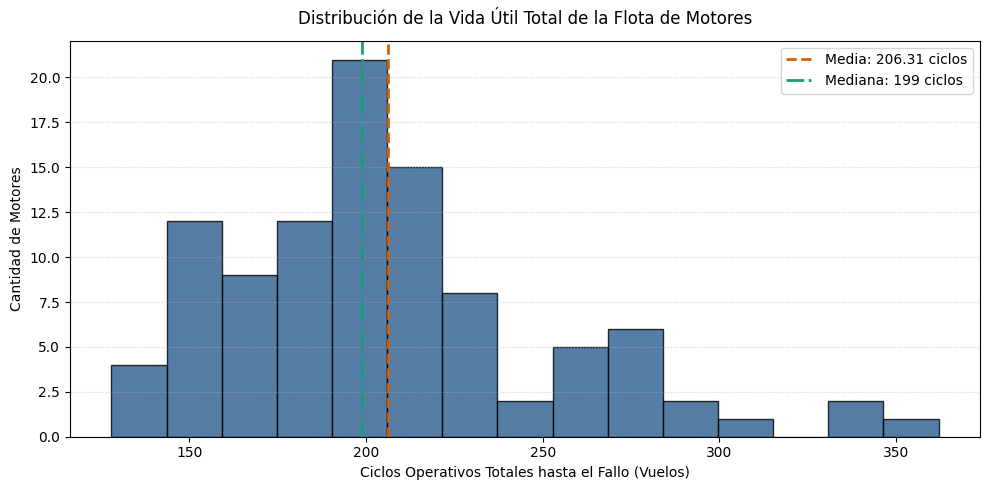

In [5]:
vida_util_motores = (
    train_df_filtro.groupby("engine_id")["cycle"]
    .max()
    .rename("max_cycles")
    .reset_index()
)

media = vida_util_motores["max_cycles"].mean()
mediana = vida_util_motores["max_cycles"].median()

plt.figure(figsize=(10, 5))
plt.hist(
    vida_util_motores["max_cycles"],
    bins=15,
    color="#2b5c8f",
    edgecolor="black",
    alpha=0.8,
)
#marca "Media"
plt.axvline(
    media,
    color="#d95f02",
    linestyle="--",
    linewidth=2,
    label=f"Media: {media:.2f} ciclos",
)
#marca "Mediana"
plt.axvline(
    mediana,
    color="#1b9e77",
    linestyle="-.",
    linewidth=2,
    label=f"Mediana: {mediana:.0f} ciclos",
)

plt.title("Distribución de la Vida Útil Total de la Flota de Motores", pad=12)
plt.xlabel("Ciclos Operativos Totales hasta el Fallo (Vuelos)")
plt.ylabel("Cantidad de Motores")
plt.legend(frameon=True)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusiones Consulta 1:**  
El promedio de durabilidad es de **206.31 ciclos**, con una mediana de **199 ciclos**. Se observa una dispersión marcada: el motor más prematuro falla en el ciclo **128**, mientras que la unidad más resistente alcanza **362 ciclos**. Esto demuestra que no es viable predecir fallas mediante un límite fijo de horas calendario, requiriendo monitoreo predictivo por condición.

### Consulta 2: Variación Porcentual Relativa de Sensores
**Pregunta:** Al comparar el estados de vida de los motores, ¿qué sensores exhiben mayor sensibilidad al desgaste y con qué signo relativo?

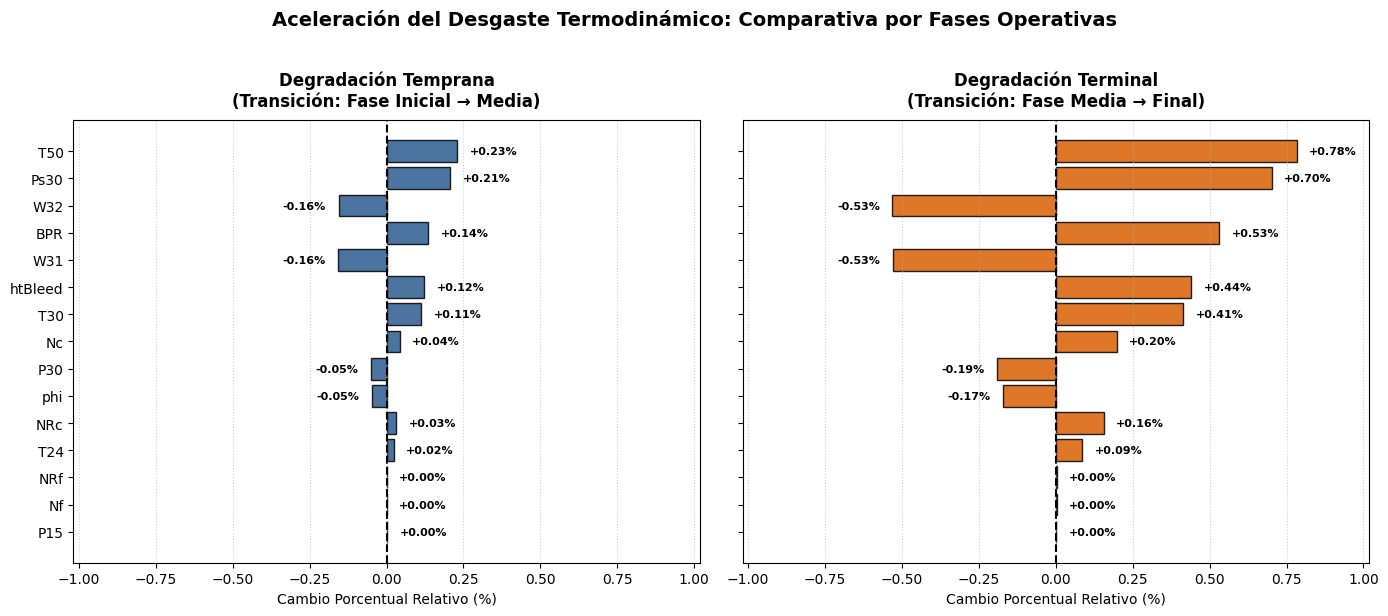

In [6]:
etapa_vida = train_df_filtro['cycle'] / (train_df_filtro['cycle'] + train_df_filtro['RUL'])

fase_inicial = train_df_filtro[etapa_vida <= 0.33][sensores_activos].mean()
fase_media = train_df_filtro[(etapa_vida > 0.33) & (etapa_vida <= 0.66)][sensores_activos].mean()
fase_final = train_df_filtro[etapa_vida > 0.66][sensores_activos].mean()
#Cambios procentuales de los sensores
cambio_ini_med = ((fase_media - fase_inicial) / fase_inicial) * 100
cambio_med_fin = ((fase_final - fase_media) / fase_media) * 100

#Ordenamos para mejor visualizacion
sensores_ordenados = cambio_med_fin.abs().sort_values().index
cambio_ini_med = cambio_ini_med[sensores_ordenados]
cambio_med_fin = cambio_med_fin[sensores_ordenados]
#1 fila, 2 columnas, comparten eje y
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
y = np.arange(len(sensores_activos))

#grafico ini-med
axes[0].barh(y, cambio_ini_med, color='#2b5c8f', edgecolor='black', alpha=0.85)
axes[0].set_yticks(y)
axes[0].set_yticklabels(sensores_ordenados)
axes[0].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[0].set_title("Degradación Temprana\n(Transición: Fase Inicial → Media)", pad=10, fontweight='bold')
axes[0].set_xlabel("Cambio Porcentual Relativo (%)")
axes[0].grid(axis="x", linestyle=":", alpha=0.6)

#grafico med-fin
axes[1].barh(y, cambio_med_fin, color='#d95f02', edgecolor='black', alpha=0.85)
axes[1].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title("Degradación Terminal\n(Transición: Fase Media → Final)", pad=10, fontweight='bold')
axes[1].set_xlabel("Cambio Porcentual Relativo (%)")
axes[1].grid(axis="x", linestyle=":", alpha=0.6)

limite_x = max(cambio_ini_med.abs().max(), cambio_med_fin.abs().max()) * 1.30
axes[0].set_xlim(-limite_x, limite_x)
axes[1].set_xlim(-limite_x, limite_x)

for ax, serie in zip(axes, [cambio_ini_med, cambio_med_fin]):
    for i, v in enumerate(serie):
        lado = "left" if v >= 0 else "right"
        offset = 0.02 * (2 * limite_x) if v >= 0 else -0.02 * (2 * limite_x)
        ax.text(v + offset, i, f"{v:+.2f}%", va="center", ha=lado, fontsize=8, fontweight="bold")

fig.suptitle("Aceleración del Desgaste Termodinámico: Comparativa por Fases Operativas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Conclusiones Consulta 2:**  
* Se observa que durante la transición inicial-media el sistema mantiene un equilibrio notable con variaciones minimas. Sin embargo, en la transición media-final, la degradación aerodinámica se acelera, haciendo que el cambio en la telemetría sea mucho más notorio.
* **Sensores que aumentan con el desgaste:** Las temperaturas ($T_{30}, T_{50}$), la relación de derivación ($BPR$), la entalpía de purga ($htBleed$) y la presión estática ($Ps_{30}$) sufren incrementos porcentuales notorios. Esto responde a la pérdida de eficiencia aerodinámica del HPC: el fluido se recalienta y el lazo de control sobreexige el flujo para mantener el empuje.

### Consulta 3: Evolución de la Temperatura de Salida del HPC ($T_{30}$)
**Pregunta:** ¿El régimen térmico con el que opera un motor turbofán influye en su durabilidad total?¿La degradación térmica escala de forma lineal desde el primer ciclo?

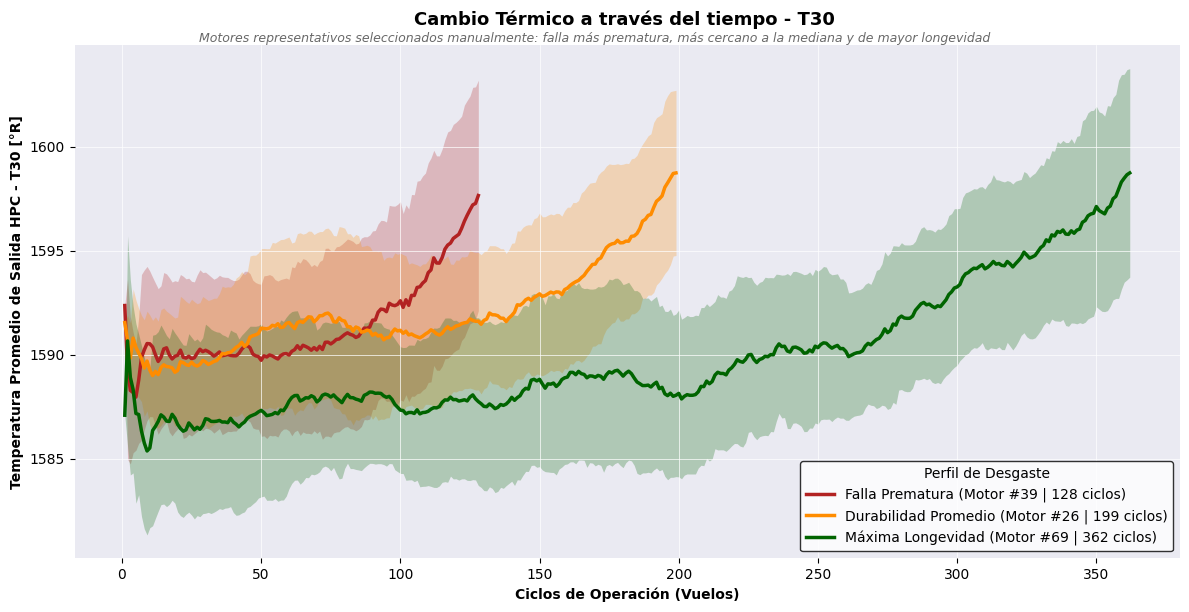

In [7]:

motor_corto = vida_util_motores.loc[vida_util_motores['max_cycles'].idxmin(), 'engine_id']
motor_medio = vida_util_motores.iloc[(vida_util_motores['max_cycles'] - vida_util_motores['max_cycles'].median()).abs().argsort()[:1]]['engine_id'].values[0]
motor_largo = vida_util_motores.loc[vida_util_motores['max_cycles'].idxmax(), 'engine_id']

motores_muestra = [motor_corto, motor_medio, motor_largo]
colores_linea = ["#B22222", "#FF8C00", "#006400"]
nombres_casos = ["Falla Prematura", "Durabilidad Promedio", "Máxima Longevidad"]

window_size = 40 # Ventana para la curva suavizada de la imagen

plt.figure(figsize=(12, 6.5))

#Configuración estética
plt.gca().set_facecolor('#EAEAF2')
plt.grid(color='white', linestyle='-', linewidth=0.5)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

for idx, engine in enumerate(motores_muestra):
    engine_data = train_df_filtro[train_df_filtro["engine_id"] == engine].copy()
    falla = engine_data["cycle"].max()

    # Promedio Móvil y Desviación Estándar
    engine_data['T30_smooth'] = engine_data['T30'].rolling(window=window_size, min_periods=1).mean()
    engine_data['T30_std'] = engine_data['T30'].rolling(window=window_size, min_periods=1).std().fillna(0)

    # Leyenda
    plt.plot(
        engine_data["cycle"],
        engine_data['T30_smooth'],
        color=colores_linea[idx],
        linewidth=2.5,
        label=f"{nombres_casos[idx]} (Motor #{engine} | {falla} ciclos)"
    )

    # Área sombreada
    plt.fill_between(
        engine_data["cycle"],
        engine_data['T30_smooth'] - engine_data['T30_std'],
        engine_data['T30_smooth'] + engine_data['T30_std'],
        color=colores_linea[idx],
        alpha=0.25,
        linewidth=0
    )

plt.title(f"Cambio Térmico a través del tiempo - T30 ", pad=15, fontsize=13, fontweight='bold')
plt.suptitle("Motores representativos seleccionados manualmente: falla más prematura, más cercano a la mediana y de mayor longevidad",
             y=0.9, fontsize=9, fontstyle='italic', color='dimgray')
plt.xlabel("Ciclos de Operación (Vuelos)", fontweight='bold')
plt.ylabel("Temperatura Promedio de Salida HPC - T30 [°R]", fontweight='bold')
plt.legend(title="Perfil de Desgaste", frameon=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.show()

**Conclusiones Consulta 3:**

El gráfico de medias móviles aislando los tres casos extremos (Falla Prematura, Durabilidad Promedio y Máxima Longevidad) permite extraer tres conclusiones fundamentales sobre la física de la degradación:

1. **El valor de operar "frío":** Se observa claramente que el motor de máxima longevidad (Motor #69, curva verde) operó durante sus primeros 200 vuelos en una franja térmica basal significativamente más baja (alrededor de 1587 °R) que los otros dos motores. Mantener este régimen térmico inferior le permitió extender su vida útil hasta los 362 ciclos.
2. **Convergencia de Colapso (Umbral Físico):** A pesar de la enorme diferencia en durabilidad (128 vs. 362 ciclos), las tres curvas convergen hacia un límite térmico superior similar. Independientemente de cuándo empezaron a fallar, el colapso terminal de los tres motores ocurre al acercarse a la barrera de los 1598 °R.
3. **Comportamiento curvo:** El desgaste de ninguna unidad trazó una línea recta. Si bien los motores de vida corta y media experimentan una "Fase Nominal" (meseta estable) que dura el 70-80% de su vida, el motor de máxima longevidad comienza a mostrar una pendiente térmica ascendente mucho antes en proporción a su vida total. Pese a estas diferencias, en todos los casos la etapa de mayor aceleración del desgaste ocurre en los últimos 40-50 vuelos ("Fase Crítica").

### Consulta 4: Detección y Análisis de Outliers en Sensor $Ps_{30}$
**Pregunta:** Los valores atípicos que surgen en los datos, ¿son lecturas ruidosas que deben eliminarse o representan la firma física de la falla terminal?

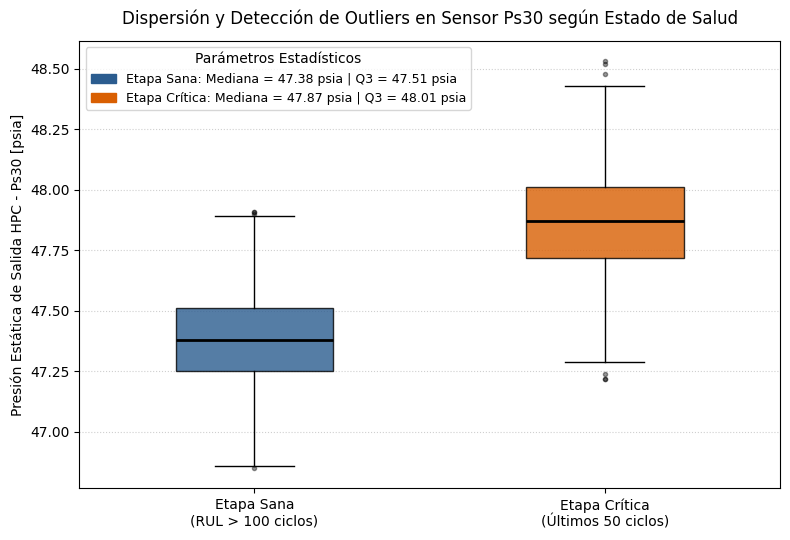

In [8]:
sanos = train_df_filtro[train_df_filtro["RUL"] > 100]["Ps30"].dropna()
criticos = train_df_filtro[train_df_filtro["RUL"] <= 50]["Ps30"].dropna()

med_s, q3_s = sanos.median(), sanos.quantile(0.75)
med_c, q3_c = criticos.median(), criticos.quantile(0.75)

plt.figure(figsize=(8, 5.5))
caja = plt.boxplot(
    [sanos, criticos],
    tick_labels=[
        "Etapa Sana\n(RUL > 100 ciclos)",
        "Etapa Crítica\n(Últimos 50 ciclos)",
    ],
    patch_artist=True,
    widths=0.45,
    flierprops=dict(
        marker="o", markersize=3, alpha=0.4, markerfacecolor="black"
    ),
)

colores_caja = ["#2b5c8f", "#d95f02"]
for patch, color in zip(caja["boxes"], colores_caja):
  patch.set_facecolor(color)
  patch.set_alpha(0.8)

for median in caja["medians"]:
  median.set(color="black", linewidth=2)

item_sano = mpatches.Patch(
    color="#2b5c8f",
    label=f"Etapa Sana: Mediana = {med_s:.2f} psia | Q3 = {q3_s:.2f} psia",
)
item_crit = mpatches.Patch(
    color="#d95f02",
    label=f"Etapa Crítica: Mediana = {med_c:.2f} psia | Q3 = {q3_c:.2f} psia",
)

plt.legend(
    handles=[item_sano, item_crit],
    loc="upper left",
    frameon=True,
    title="Parámetros Estadísticos",
    fontsize=9,
)
plt.ylabel("Presión Estática de Salida HPC - Ps30 [psia]")
plt.title(
    "Dispersión y Detección de Outliers en Sensor Ps30 según Estado de Salud",
    pad=12,
)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusiones Consulta 4:**  
Al inspeccionar mediante diagramas de caja, se comprueba que el tamaño de la caja se mantiene estable, pero ocurre un **desplazamiento en bloque hacia arriba**: la mediana sube de $47.38$ a $47.87\text{ psia}$.

Los valores más extremos ($> 48.00\text{ psia}$) aparecen de forma sistemática en los últimos 50 vuelos. Esto demuestra que los puntos clasificados como *outliers* (puntos por fuera de los bigotes) no son fallas de medición, sino la sobrepresión real previa al colapso. **No deben eliminarse**, ya que purgar estos registros eliminaría el patrón exacto de falla que debemos aprender a detectar.

### Consulta 5: Matriz de Correlación Cruzada entre Sensores (Detección de Redundancia)
**Pregunta:** Dado que múltiples variables se alteran en simultáneo, ¿aportan información independiente o existe una fuerte colinealidad que justifique reducir la dimensionalidad?

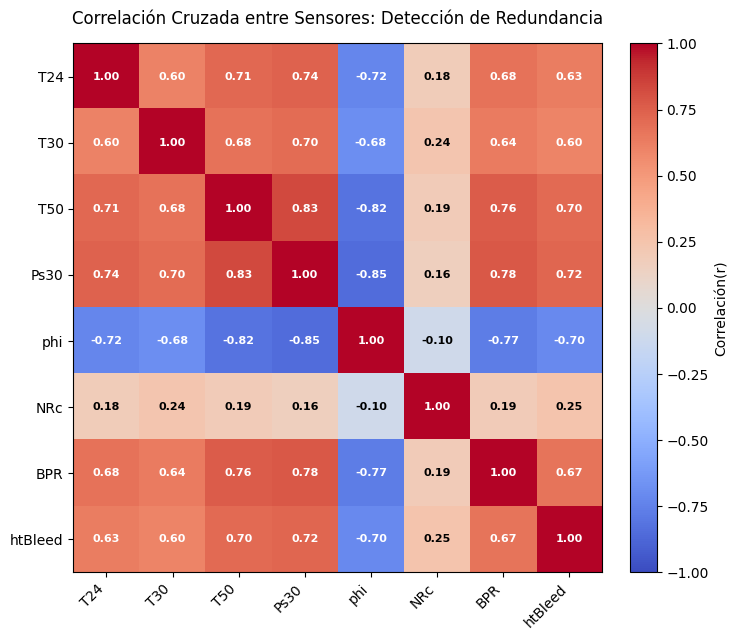

In [9]:
sensores_clave = ["T24", "T30", "T50", "Ps30", "phi", "NRc", "BPR", "htBleed"]
df_corr = train_df_filtro[sensores_clave].corr()

plt.figure(figsize=(8, 6.5))
matriz = df_corr.values

im = plt.imshow(matriz, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlación(r)")

plt.xticks(range(len(sensores_clave)), sensores_clave, rotation=45, ha="right")
plt.yticks(range(len(sensores_clave)), sensores_clave)
plt.title("Correlación Cruzada entre Sensores: Detección de Redundancia", pad=14)

for i in range(len(sensores_clave)):
  for j in range(len(sensores_clave)):
    color_texto = "white" if abs(matriz[i, j]) > 0.55 else "black"
    plt.text(
        j,
        i,
        f"{matriz[i, j]:.2f}",
        ha="center",
        va="center",
        color=color_texto,
        fontsize=8,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

**Conclusiones Consulta 5:**  

**Colinealidad térmica y de presión:** Existe una fuerte correlación positiva ($r$ entre $0.60$ y $0.83$) entre $T_{24}, T_{30}, T_{50}, Ps_{30}, BPR$ y $htBleed$. Físicamente, el sobrecalentamiento del HPC genera un aumento simultáneo de contrapresión y arrastre térmico a la turbina.

**Redundancia inversa:** La variable $phi$ evoluciona en sentido exactamente inverso ($r \approx -0.85$ con $Ps_{30}$ y $-0.82$ con $T_{50}$), aportando la misma trayectoria de degradación bajo signo opuesto.

**Justificación de reducción dimensional:** La alta interdependencia lineal confirma que el sistema no requiere 8 dimensiones efectivas para describirse.

# SPARK

In [10]:
# INICIALIZACIÓN DE SPARK Y PREPARACIÓN DEL RDD
from pyspark.sql import SparkSession

# Creamos la sesión de Spark
spark = SparkSession.builder.appName("TP_CMAPSS_Spark").getOrCreate()

# Convertimos el dataset limpio de Pandas a un DataFrame de Spark, y luego a RDD
spark_df = spark.createDataFrame(train_df_filtro)
rdd_base = spark_df.rdd.cache()

### Consulta 1: Vida útil máxima de cada motor
**Pregunta:** Cuantos ciclos duro cada motor antes de fallar, podriamos realizar un mantenimiento a los motores cada una cierta cantidad de ciclos?


In [11]:
vida_util_rdd = (
    rdd_base
    .map(lambda row: (int(row["engine_id"]), int(row["cycle"])))
    .reduceByKey(lambda a, b: a if (a > b) else b)
).cache()

minimo = vida_util_rdd.map(lambda x: x[1]).reduce(lambda a, b: a if (a < b) else b)
maximo = vida_util_rdd.map(lambda x: x[1]).reduce(lambda a, b: a if (a > b) else b)

print(f"minima duracion: {minimo}")
print(f"maxima duracion: {maximo}")

minima duracion: 128
maxima duracion: 362


**Conclusiones Consulta 1:**  
Los resultados demuestran una altísima dispersión operativa, existen unidades que colapsan a los 128 ciclos, mientras que otras llegaron a los 362 vuelos de operatividad.
Estadisticamente podriamos dejar como cota inferior de mantenimiento a los 128 ciclos.

## Consulta 2: Promedio térmico histórico
**Pregunta:** Calcular la temperatura promedio exacta ($T_{30}$) que soportó cada motor en toda su vida, para ver si los que fallaron antes operaban más calientes.


Coeficiente de correlación de Pearson (r): -0.194


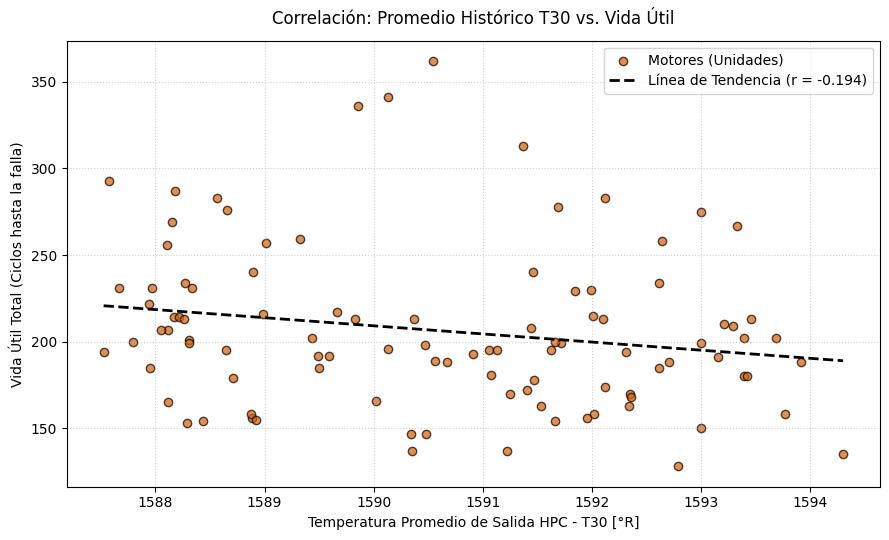

In [12]:
analisis_termico_rdd = (
    rdd_base
    .map(lambda row: (int(row["engine_id"]), (float(row["T30"]), 1)))
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .mapValues(lambda totales: (totales[0] / totales[1], totales[1]))
)

datos_completos = analisis_termico_rdd.collect()

# item = (engine_id, (prom_t30, ciclos))
promedios_t30 = [item[1][0] for item in datos_completos]
vida_util = [item[1][1] for item in datos_completos]

r_pearson = np.corrcoef(promedios_t30, vida_util)[0, 1]
print(f"Coeficiente de correlación de Pearson (r): {r_pearson:.3f}")

# Calculamos la línea de tendencia
z = np.polyfit(promedios_t30, vida_util, 1)
p = np.poly1d(z)
tendencia_x = np.linspace(min(promedios_t30), max(promedios_t30), 100)

# Graficos
plt.figure(figsize=(9, 5.5))
plt.scatter(promedios_t30, vida_util, color="#d95f02", alpha=0.7, edgecolors="black", label="Motores (Unidades)")
plt.plot(tendencia_x, p(tendencia_x), color="black", linestyle="--", linewidth=2, label=f"Línea de Tendencia (r = {r_pearson:.3f})")
plt.title("Correlación: Promedio Histórico T30 vs. Vida Útil", pad=12)
plt.xlabel("Temperatura Promedio de Salida HPC - T30 [°R]")
plt.ylabel("Vida Útil Total (Ciclos hasta la falla)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusiones Consulta 2:**

Se observa una tendencia negativa entre la temperatura promedio histórica de salida T30 y la vida útil del motor, pero el coeficiente de correlación de Pearson ($r = -0.194$) confirma que esta relación lineal es sumamente débil.
La alta dispersión de la nube de puntos demuestra que la temperatura promedio de toda la vida operativa no dicta por sí sola el momento del colapso.

## Consulta 3: Limite de temperatura soportado y el ciclo de falla

**Pregunta:**

 Basándonos en la inspección visual del sensor térmico T30 (Consulta 2 de Pandas), se hipotetiza que la falla estructural del motor no está dictada por una cantidad de ciclos límite, sino por una "barrera termodinámica". Se espera que todos los motores de la flota, independientemente de si vivieron 130 o 350 vuelos, alcancen la misma temperatura de salida ($T_{30}$) en su ciclo de colapso.

In [14]:
# Emitimos la tupla (engine_id, (T30_Final, Ciclo_Final))
limite_termodinamico_rdd = (
    rdd_base
    .filter(lambda row: int(row["RUL"]) == 0)
    .map(lambda row: (int(row["engine_id"]), (float(row["T30"]), int(row["cycle"]))))
).cache()

stats_temp = limite_termodinamico_rdd.map(lambda x: x[1][0]).stats()

temp_min = stats_temp.min()
temp_max = stats_temp.max()
temp_media = stats_temp.mean()

print("-" * 80)
print("Comprobación del Límite Termodinámico en el Ciclo de Falla (T30):")
print("-" * 80)
print(f"- Temperatura final más baja registrada: {temp_min:.2f} °R")
print(f"- Temperatura final más alta registrada: {temp_max:.2f} °R")
print(f"- TEMPERATURA MEDIA DE COLAPSO: {temp_media:.2f} °R")
print("-" * 80)

categorias_rdd = limite_termodinamico_rdd.map(
    lambda x: ("Prematuro" if x[1][1] < 150 else "Longevo" if x[1][1] > 250 else "Estándar", x[1][0])
)
promedio_por_categoria = (
    categorias_rdd
    .mapValues(lambda t30: (t30, 1))
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .mapValues(lambda x: x[0] / x[1])
    .collect()
)
print("-" * 80)
print("Promedio de T30 final por categoría de longevidad:")
for categoria, promedio in sorted(promedio_por_categoria):
    print(f"- {categoria}: {promedio:.2f} °R")
print("-" * 80)

--------------------------------------------------------------------------------
Comprobación del Límite Termodinámico en el Ciclo de Falla (T30):
--------------------------------------------------------------------------------
- Temperatura final más baja registrada: 1592.45 °R
- Temperatura final más alta registrada: 1612.63 °R
- TEMPERATURA MEDIA DE COLAPSO: 1602.50 °R
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Promedio de T30 final por categoría de longevidad:
- Estándar: 1602.64 °R
- Longevo: 1602.42 °R
- Prematuro: 1600.96 °R
--------------------------------------------------------------------------------


**Conclusiones Consulta 3:**

Al observar los promedios por tiempo de vida, vemos que en los 3 casos fallan al llegar a un rango muy acotado de temperatura. Esto demuestra que la variable temporal (ciclos) no rompe el motor; lo que dictamina la falla es el límite de fluencia térmica del material. Un motor "bueno" no es aquel capaz de resistir temperaturas finales más altas, sino aquel que logra retrasar la llegada a esta barrera crítica de los 1600 °R aproximadamente operando con un régimen basal más frío.

Tambien hay que tener en cuenta de que algunos motores llegaron a aguantar solo 1592.45°R entonces no deberiamos hacer mucho caso al promedio sino a la cota inferior.

## Consulta 4: Detección del primer ciclo crítico (Ps30)

Como en la consulta anterior estudiamos el limite estructural del motor con el sensor T30, ahora estudiemos un método para la prevención de la falla, como vimos en la Consulta 5 de pandas, el sensor Ps30 y el T30 estan altamente correlacionados,el aumento irregular de la presión estática ($Ps_{30}$) representa el esfuerzo aerodinámico que compensa la degradación y causa el sobrecalentamiento del motor. Este análisis será para hallar la causa de la consecuencia (aumento de temperatura fatal).

**Pregunta:** ¿En qué ciclo exacto cada motor superó por primera vez ese nivel crítico de presión? Se puede hallar un periodo de tiempo para que el equipo de mantenimiento pueda retirar el motor antes de la falla?

In [15]:
#REDONDEAMOS EL UMBRAL
UMBRAL_CRITICO_PS30 = 47.9

vuelos_peligro_rdd = rdd_base.filter(lambda row: float(row["Ps30"]) > UMBRAL_CRITICO_PS30)

punto_inflexion_rdd = (
    vuelos_peligro_rdd
    .map(lambda row: (int(row["engine_id"]), int(row["cycle"])))
    .reduceByKey(lambda a, b: a if (a < b) else b)
)
analisis_critico_rdd = punto_inflexion_rdd.join(vida_util_rdd).cache()

metricas_sobrevida_rdd = analisis_critico_rdd.map(
    lambda x: (x[1][1] - x[1][0], ((x[1][1] - x[1][0]) / x[1][1]) * 100)
).cache()

resultados_critico = analisis_critico_rdd.take(10)
motores_detectados = analisis_critico_rdd.count()

stats_vuelos = metricas_sobrevida_rdd.map(lambda x: x[0]).stats()
peor_escenario = stats_vuelos.min()
margen_maximo = stats_vuelos.max()

stats_pct = metricas_sobrevida_rdd.map(lambda x: x[1]).stats()
pct_sobrevida_media = stats_pct.mean()

motores_totales = vida_util_rdd.count()
falsos_negativos = motores_totales - motores_detectados

print(f"(Mostrando 10 casos de muestra sobre un total de {motores_detectados} motores detectados)")

print("-" * 85)
print(f"Detección Temprana: Primer vuelo superando el umbral crítico ({UMBRAL_CRITICO_PS30} psia)")
print("-" * 85)
for motor, (ciclo_critico, ciclo_final) in resultados_critico:
    vuelos_restantes = ciclo_final - ciclo_critico
    pct_sobrevida = (vuelos_restantes / ciclo_final) * 100
    print(f"Motor #{motor:03d} | Alarma en ciclo: {ciclo_critico:03d} | Falla en: {ciclo_final:03d} | Sobrevivió: {vuelos_restantes:02d} vuelos ({pct_sobrevida:.1f}% de su vida)")

print("-" * 85)
print(f"KPI de Confiabilidad del Umbral {UMBRAL_CRITICO_PS30} psia:")
print(f"- Motores analizados: {motores_totales}")
print(f"- Falsos Negativos (Fallaron sin llegar al umbral): {falsos_negativos}")
print(f"- Margen de maniobra promedio (sobre los {motores_detectados} motores): {pct_sobrevida_media:.1f}% de su vida útil")
print(f"- El margen mínimo de maniobra histórico fue de: {peor_escenario} vuelos")
print(f"- El margen máximo de maniobra histórico fue de: {margen_maximo} vuelos")

(Mostrando 10 casos de muestra sobre un total de 100 motores detectados)
-------------------------------------------------------------------------------------
Detección Temprana: Primer vuelo superando el umbral crítico (47.9 psia)
-------------------------------------------------------------------------------------
Motor #002 | Alarma en ciclo: 251 | Falla en: 287 | Sobrevivió: 36 vuelos (12.5% de su vida)
Motor #004 | Alarma en ciclo: 163 | Falla en: 189 | Sobrevivió: 26 vuelos (13.8% de su vida)
Motor #006 | Alarma en ciclo: 127 | Falla en: 188 | Sobrevivió: 61 vuelos (32.4% de su vida)
Motor #008 | Alarma en ciclo: 106 | Falla en: 150 | Sobrevivió: 44 vuelos (29.3% de su vida)
Motor #010 | Alarma en ciclo: 193 | Falla en: 222 | Sobrevivió: 29 vuelos (13.1% de su vida)
Motor #012 | Alarma en ciclo: 129 | Falla en: 170 | Sobrevivió: 41 vuelos (24.1% de su vida)
Motor #014 | Alarma en ciclo: 155 | Falla en: 180 | Sobrevivió: 25 vuelos (13.9% de su vida)
Motor #016 | Alarma en ciclo: 1

**Conclusiones Consulta 4:**

Se observa que una vez que el motor cruza la barrera de los
$47.90$ $psia$, ingresa a una fase de riesgo elevado: en la mayoría de los casos sobrevive con un margen promedio del 19.4% adicional. En los motores detectados, el margen mínimo de maniobra fue de 10 vuelos y el máximo llegó a 112 vuelos. Sin embargo, tomando la muestra de 10 motores, en 4 de los 10 motores analizados el margen de maniobra superó el 29% de vida útil restante, llegando hasta un 41% extra en el caso más favorable, por lo que el umbral debe leerse como un fuerte indicador de riesgo pero no garantiza el colapso inmediato del motor.

# Metodología y Conclusiones Principales del Análisis Exploratorio

**Métodos Aplicados:**
Para el análisis se implementaron técnicas de suavizado temporal (Medias Móviles y Desviación Estándar) para filtrar el ruido de alta frecuencia en la telemetría térmica. El análisis de varianza estructural se abordó segmentando la vida útil normalizada en terciles (Fase Inicial, Media y Final). Por su parte, la extracción de características distribuidas (Time-to-Failure, Umbrales) se resolvió en el clúster de PySpark mediante la topología algorítmica *Map-Reduce* y el uso de operaciones relacionales (`Join`).
Tras aplicar técnicas de análisis descriptivo en Pandas y procesamiento distribuido mediante el paradigma Map-Reduce en Spark, se establecen las siguientes conclusiones fundamentales sobre el dataset C-MAPSS de la NASA (FD001):

### 1. El mantenimiento preventivo por calendario es inviable
El análisis del RUL demostró una dispersión extrema en la durabilidad, oscilando entre los 128 y los 362 ciclos operativos bajo idénticas condiciones de vuelo. Esto desmiente la eficacia del mantenimiento preventivo tradicional cada ciertos ciclos de operación.

### 2. La degradación termodinámica no es lineal
El desgaste del módulo HPC (Compresor de Alta Presión) exhibe un comportamiento asintótico. Durante el 70-80% de la vida útil del motor, las variables termodinámicas fluctúan en una banda nominal estrecha. Sin embargo, en los últimos 40-50 vuelos, se registra una aceleración terminal caracterizada por un incremento abrupto de las temperaturas ($T_{30}, T_{50}$) y la presión estática ($Ps_{30}$).

### 3. Alta colinealidad y redundancia sensórica
La matriz de correlación cruzada determinó un fuerte acoplamiento físico ($r$  entre  0.60  y  0.83) entre los sensores térmicos, de presión y de sangrado de aire. Esta alta redundancia confirma que los datos residen en un subespacio de menor dimensión, justificando la necesidad de poder aplicar técnicas de reducción de dimensionalidad (como PCA o SVD) en las próximas etapas del análisis.

### 4. Reclasificación de "Outliers" como firma de falla crítica
El análisis de cajas y el filtrado en clúster comprobaron que los valores extremos, particularmente cuando $Ps_{30} > 47.90\ o\  48\text{ psia}$, no constituyen ruido de medición. Representan la sobrepresión real del sistema intentando compensar la ineficiencia aerodinámica terminal. El pipeline de detección temprana confirmó que, al cruzar este umbral, los motores entran en estado crítico (con casos extremos registrando un margen de maniobra de apenas 10 vuelos antes del colapso total).

### 5. El Sensor Ps30 como sensor de prediccion (Umbral de Falla Inminente)
El análisis corroboró que el cruce de la presión estática del HPC ($Ps_{30}$) por encima del umbral de $47.90\text{ psia}$ opera como un indicador casi infalible del inicio de la agonía mecánica del motor.
Las métricas extraídas validan que el margen operativo promedio es cercano al 19% de su vida útil total. Asimismo, el bajísimo índice de falsos negativos comprobado en Spark (motores que colapsan sin activar esta sobrepresión) posiciona al umbral $Ps_{30}$ como la variable principal a priorizar para una regla de alerta programada dentro del modelo de Mantenimiento Basado en Condición.